# Supervised Classification

3 models:
1. naive bayes
2. BERT (pretrained then finetuned)
3. RNN ensemble


In [2]:
print("hi")

hi


In [3]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
#load the tagged data
df= pd.read_csv('Data/ML_tagged_data-TITLES.csv')
print(df.shape)
df.head()

(3928, 3)


,URL,Title,User_Needs
0,http://www.pressherald.com/2026/01/09/gray-inv...,Gray investigated for buying $1.25M fire truck...,update-me
1,http://www.pressherald.com/2026/01/28/ice-agen...,"ICE agents shatter window, leave 1-month-old b...",give-me-perspective
2,http://www.pressherald.com/2025/10/21/graham-p...,Graham Platner says he will remove a Nazi-link...,educate-me
3,http://www.pressherald.com/2025/09/24/trump-ad...,Trump administration cancels USM college progr...,update-me
4,http://www.pressherald.com/2026/01/23/ice-watc...,ICE watchers in Maine say they were threatened...,update-me


In [5]:
#check class distribution
print(df['User_Needs'].value_counts())
print()
print(df['User_Needs'].value_counts(normalize=True).round(3))

User_Needs
update-me              1956
give-me-perspective     738
educate-me              594
connect-me              312
inspire-me              223
help-me                 105
Name: count, dtype: int64

User_Needs
update-me              0.498
give-me-perspective    0.188
educate-me             0.151
connect-me             0.079
inspire-me             0.057
help-me                0.027
Name: proportion, dtype: float64


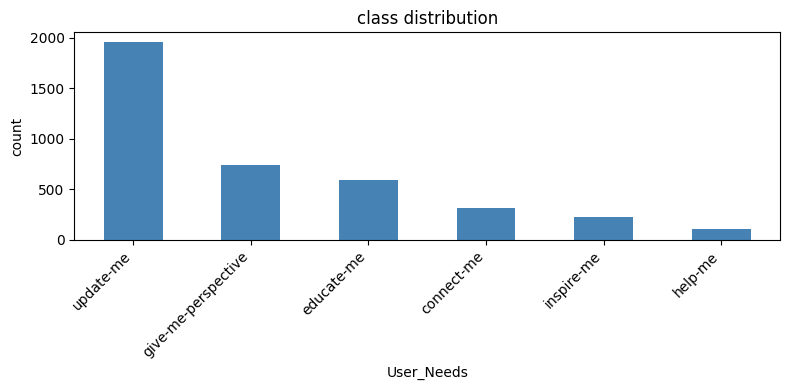

In [6]:
#quick bar chart of class balance
fig,ax =plt.subplots(figsize=(8,4))
df['User_Needs'].value_counts().plot(kind='bar',ax=ax, color='steelblue')
ax.set_title('class distribution')
ax.set_ylabel('count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

## preprocessing

clean up titles, encode labels, split data

In [7]:
#basic text cleaning
import re

def clean_txt(text):
    #lowercase and remove special chars
    text= str(text).lower()
    text =re.sub(r'[^a-z0-9\s]','',text)
    text= re.sub(r'\s+',' ', text).strip()
    return text

df['clean_title'] =df['Title'].apply(clean_txt)
df['clean_title'].head()

0    gray investigated for buying 125m fire truck w...
1    ice agents shatter window leave 1monthold baby...
2    graham platner says he will remove a nazilinke...
3    trump administration cancels usm college progr...
4    ice watchers in maine say they were threatened...
Name: clean_title, dtype: str

In [8]:
#encode the labels
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()
df['label'] =le.fit_transform(df['User_Needs'])

#save the mapping
label_map= dict(zip(le.classes_,le.transform(le.classes_)))
print(label_map)
num_classes =len(label_map)
print(f'\nnumber of classes: {num_classes}')

{'connect-me': np.int64(0), 'educate-me': np.int64(1), 'give-me-perspective': np.int64(2), 'help-me': np.int64(3), 'inspire-me': np.int64(4), 'update-me': np.int64(5)}

number of classes: 6


In [9]:
#train test split
X_train,X_test, y_train,y_test= train_test_split(
    df['clean_title'], df['label'],
    test_size=0.2,random_state=42, stratify=df['label']
)

print(f'train size: {len(X_train)}')
print(f'test size: {len(X_test)}')

train size: 3142
test size: 786


---
## Model 1: Naive Bayes Classifier


In [10]:
#tfidf vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf =TfidfVectorizer(max_features=5000, ngram_range=(1,2),stop_words='english')
X_train_tfidf= tfidf.fit_transform(X_train)
X_test_tfidf =tfidf.transform(X_test)

print(f'tfidf matrix shape: {X_train_tfidf.shape}')

tfidf matrix shape: (3142, 5000)


In [11]:
#train naive bayes
from sklearn.naive_bayes import MultinomialNB

nb_model= MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf,y_train)

#predictions
nb_preds =nb_model.predict(X_test_tfidf)

In [12]:
#naive bayes results
print('=== Naive Bayes Results ===')
print(f'accuracy: {accuracy_score(y_test,nb_preds):.4f}')
print()
print(classification_report(y_test, nb_preds,target_names=le.classes_))

=== Naive Bayes Results ===
accuracy: 0.6145

                     precision    recall  f1-score   support

         connect-me       0.62      0.08      0.14        62
         educate-me       0.67      0.13      0.22       119
give-me-perspective       0.86      0.53      0.65       148
            help-me       0.00      0.00      0.00        21
         inspire-me       0.00      0.00      0.00        45
          update-me       0.58      0.98      0.73       391

           accuracy                           0.61       786
          macro avg       0.45      0.29      0.29       786
       weighted avg       0.60      0.61      0.53       786



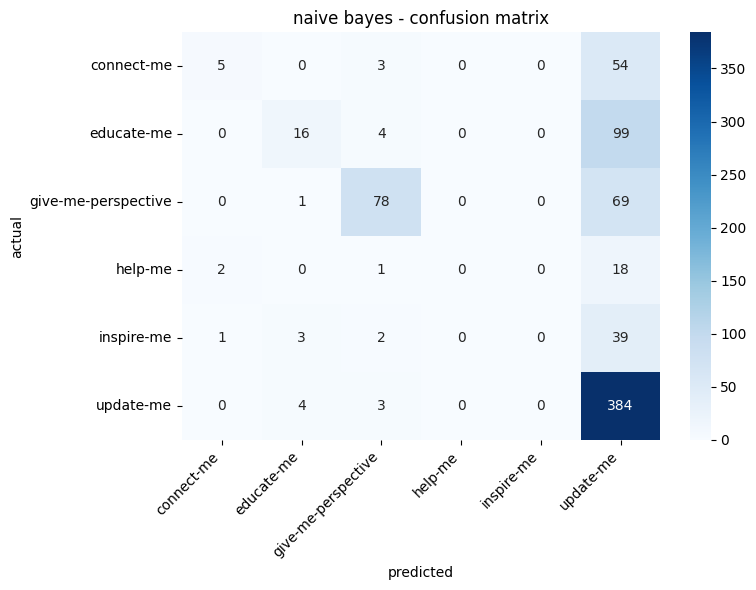

In [13]:
#confusion matrix for nb
fig,ax= plt.subplots(figsize=(8,6))
cm_nb =confusion_matrix(y_test,nb_preds)
sns.heatmap(cm_nb,annot=True, fmt='d',cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,ax=ax)
ax.set_title('naive bayes - confusion matrix')
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Model 2: BERT

### pretrained BERT (zero-shot with pipeline)




In [14]:
#install transformers if needed
#!pip install transformers torch

from transformers import pipeline

#zero shot classifier
zs_classifier =pipeline('zero-shot-classification',model='facebook/bart-large-mnli')

#the candidate labels are our user needs categories
candidate_labels= list(le.classes_)
print('candidate labels:',candidate_labels)

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 7888.44it/s]


candidate labels: ['connect-me', 'educate-me', 'give-me-perspective', 'help-me', 'inspire-me', 'update-me']


In [15]:
#run zero shot on test set
#this takes a while so we sample if needed
from tqdm import tqdm

sample_size= min(200, len(X_test))
test_sample =X_test.iloc[:sample_size].tolist()
y_sample= y_test.iloc[:sample_size].tolist()

zs_preds= []
for title in tqdm(test_sample,desc='zero-shot'):
    result =zs_classifier(title,candidate_labels)
    #get top prediction
    top_label= result['labels'][0]
    zs_preds.append(le.transform([top_label])[0])

zero-shot: 100%|██████████| 200/200 [03:12<00:00,  1.04it/s]


In [16]:
#zero shot results
print('=== BERT Zero-Shot Results ===')
print(f'accuracy (on {sample_size} samples): {accuracy_score(y_sample,zs_preds):.4f}')
print()
print(classification_report(y_sample,zs_preds, target_names=le.classes_))

=== BERT Zero-Shot Results ===
accuracy (on 200 samples): 0.2050

                     precision    recall  f1-score   support

         connect-me       0.00      0.00      0.00        18
         educate-me       0.11      0.08      0.09        25
give-me-perspective       0.25      0.58      0.34        45
            help-me       0.11      0.12      0.12         8
         inspire-me       0.08      0.11      0.09         9
          update-me       0.85      0.12      0.20        95

           accuracy                           0.20       200
          macro avg       0.23      0.17      0.14       200
       weighted avg       0.48      0.20      0.19       200



### fine-tuned BERT


In [17]:
print("hi")

hi


In [18]:
#setup for finetuning
#!pip install transformers torch datasets

from transformers import BertTokenizer,BertForSequenceClassification
from transformers import Trainer,TrainingArguments
from torch.utils.data import Dataset
import torch

#check if gpu available
device= 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'using device: {device}')

using device: cpu


In [19]:
#custom dataset class
class TitleDataset(Dataset):
    def __init__(self,texts, labels,tokenizer,max_len=64):
        self.texts =texts
        self.labels= labels
        self.tokenizer =tokenizer
        self.max_len= max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self,idx):
        text= str(self.texts.iloc[idx]) if hasattr(self.texts,'iloc') else str(self.texts[idx])
        label =self.labels.iloc[idx] if hasattr(self.labels,'iloc') else self.labels[idx]
        
        encoding= self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask':encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label,dtype=torch.long)
        }

In [20]:
#tokenizer and model
tokenizer= BertTokenizer.from_pretrained('bert-base-uncased')
bert_model =BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes
)

#create datasets
train_dataset= TitleDataset(X_train, y_train,tokenizer)
test_dataset =TitleDataset(X_test,y_test, tokenizer)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7461.44it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

In [21]:
#training args
training_args= TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

#accuracy metric
from sklearn.metrics import accuracy_score as acc_score
import numpy as np

def compute_metrics(eval_pred):
    logits,labels= eval_pred
    preds =np.argmax(logits,axis=-1)
    return {'accuracy': acc_score(labels,preds)}

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [22]:
#train the model
trainer =Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.137612,1.026187,0.624682
2,0.884520,0.979755,0.647583
3,0.522724,1.028301,0.655216
4,0.322351,1.126103,0.670483


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.47it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=788, training_loss=0.7281586482440154, metrics={'train_runtime': 1568.9269, 'train_samples_per_second': 8.011, 'train_steps_per_second': 0.502, 'total_flos': 413362313091072.0, 'train_loss': 0.7281586482440154, 'epoch': 4.0})

In [26]:
#evaluate finetuned bert (workaround)
bert_model.eval()
bert_output =trainer.predict(test_dataset)
bert_preds= np.argmax(bert_output.predictions,axis=-1)

bert_acc =accuracy_score(y_test,bert_preds)
print('=== Fine-tuned BERT Results ===')
print(f'accuracy: {bert_acc:.4f}')
print()
print(classification_report(y_test,bert_preds, target_names=le.classes_))

=== Fine-tuned BERT Results ===
accuracy: 0.6705

                     precision    recall  f1-score   support

         connect-me       0.41      0.32      0.36        62
         educate-me       0.37      0.33      0.35       119
give-me-perspective       0.73      0.61      0.67       148
            help-me       0.43      0.29      0.34        21
         inspire-me       0.56      0.53      0.55        45
          update-me       0.77      0.89      0.82       391

           accuracy                           0.67       786
          macro avg       0.54      0.50      0.52       786
       weighted avg       0.65      0.67      0.66       786



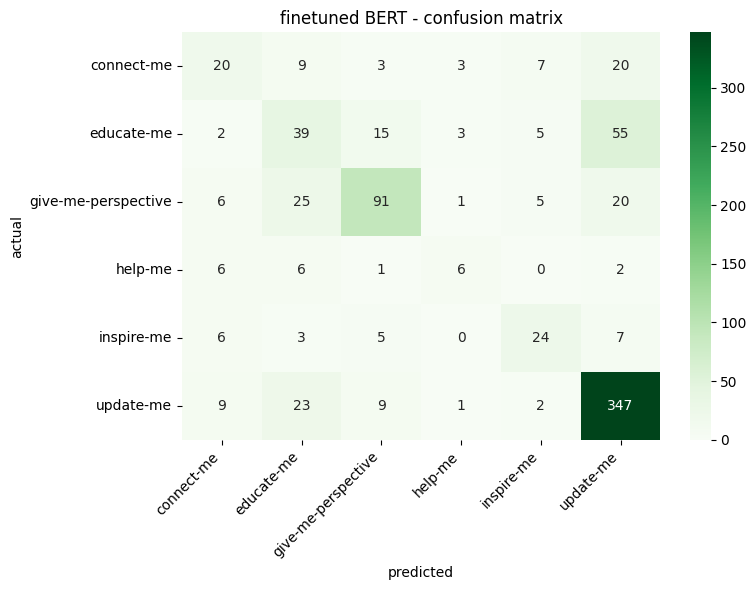

In [27]:
#confusion matrix for bert
fig,ax =plt.subplots(figsize=(8,6))
cm_bert= confusion_matrix(y_test,bert_preds)
sns.heatmap(cm_bert,annot=True,fmt='d', cmap='Greens',
            xticklabels=le.classes_,yticklabels=le.classes_, ax=ax)
ax.set_title('finetuned BERT - confusion matrix')
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Model 3: RNN Ensemble



In [28]:
#rnn setup
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset
from collections import Counter

#build vocab from training data
def build_vocab(texts,max_vocab=8000):
    #count all words
    word_counts =Counter()
    for t in texts:
        word_counts.update(t.split())
    
    #most common words get indices
    vocab= {'<PAD>':0,'<UNK>':1}
    for word,_ in word_counts.most_common(max_vocab):
        vocab[word]= len(vocab)
    return vocab

vocab =build_vocab(X_train)
print(f'vocab size: {len(vocab)}')

vocab size: 6434


In [29]:
#text to sequences
def text_to_seq(texts,vocab, max_len=32):
    seqs= []
    for t in texts:
        words =t.split()
        seq= [vocab.get(w,1) for w in words[:max_len]]
        #pad if needed
        if len(seq)<max_len:
            seq= seq + [0]*(max_len -len(seq))
        seqs.append(seq)
    return np.array(seqs)

max_len=32
X_train_seq =text_to_seq(X_train, vocab,max_len)
X_test_seq= text_to_seq(X_test,vocab,max_len)

#to tensors
X_train_t =torch.LongTensor(X_train_seq)
y_train_t= torch.LongTensor(y_train.values)
X_test_t =torch.LongTensor(X_test_seq)
y_test_t= torch.LongTensor(y_test.values)

#dataloaders
train_ds= TensorDataset(X_train_t, y_train_t)
test_ds =TensorDataset(X_test_t,y_test_t)
train_loader= DataLoader(train_ds,batch_size=32, shuffle=True)
test_loader =DataLoader(test_ds,batch_size=64)

In [30]:
#define rnn models
class LSTMClassifier(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim, num_classes,dropout=0.3):
        super().__init__()
        self.embedding =nn.Embedding(vocab_size,embed_dim, padding_idx=0)
        self.lstm= nn.LSTM(embed_dim,hidden_dim, batch_first=True,bidirectional=False, dropout=dropout,num_layers=2)
        self.fc =nn.Linear(hidden_dim, num_classes)
        self.drop= nn.Dropout(dropout)
    
    def forward(self,x):
        emb =self.drop(self.embedding(x))
        _,(hidden,_)= self.lstm(emb)
        out= self.fc(self.drop(hidden[-1]))
        return out

class GRUClassifier(nn.Module):
    def __init__(self,vocab_size, embed_dim,hidden_dim,num_classes, dropout=0.3):
        super().__init__()
        self.embedding= nn.Embedding(vocab_size,embed_dim,padding_idx=0)
        self.gru =nn.GRU(embed_dim,hidden_dim,batch_first=True, bidirectional=False,dropout=dropout, num_layers=2)
        self.fc= nn.Linear(hidden_dim,num_classes)
        self.drop =nn.Dropout(dropout)
    
    def forward(self,x):
        emb= self.drop(self.embedding(x))
        _,hidden =self.gru(emb)
        out =self.fc(self.drop(hidden[-1]))
        return out

class BiLSTMClassifier(nn.Module):
    def __init__(self,vocab_size,embed_dim, hidden_dim,num_classes,dropout=0.3):
        super().__init__()
        self.embedding =nn.Embedding(vocab_size, embed_dim,padding_idx=0)
        self.lstm =nn.LSTM(embed_dim,hidden_dim, batch_first=True,bidirectional=True,dropout=dropout, num_layers=2)
        self.fc= nn.Linear(hidden_dim*2,num_classes)
        self.drop =nn.Dropout(dropout)
    
    def forward(self,x):
        emb= self.drop(self.embedding(x))
        _, (hidden,_) =self.lstm(emb)
        #concat both directions
        hidden_cat= torch.cat((hidden[-2],hidden[-1]), dim=1)
        out =self.fc(self.drop(hidden_cat))
        return out

print('models defined')

models defined


In [31]:
#training function
def train_rnn(model,train_loader, epochs=15,lr=0.001):
    model.to(device)
    optimizer =torch.optim.Adam(model.parameters(),lr=lr)
    criterion= nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss= 0
        for batch_x,batch_y in train_loader:
            batch_x,batch_y =batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            output =model(batch_x)
            loss= criterion(output,batch_y)
            loss.backward()
            optimizer.step()
            total_loss +=loss.item()
        
        if (epoch+1)%5==0:
            avg =total_loss/len(train_loader)
            print(f'epoch {epoch+1}/{epochs} - loss: {avg:.4f}')
    
    return model

#get predictions from a model
def get_preds(model,loader):
    model.eval()
    all_preds =[]
    with torch.no_grad():
        for batch_x,batch_y in loader:
            batch_x= batch_x.to(device)
            output =model(batch_x)
            preds= torch.argmax(output,dim=1)
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)

In [32]:
#model params
vsize =len(vocab)
embed_dim= 128
hidden_dim =64

#init models
lstm_model= LSTMClassifier(vsize,embed_dim, hidden_dim,num_classes)
gru_model =GRUClassifier(vsize,embed_dim,hidden_dim, num_classes)
bilstm_model= BiLSTMClassifier(vsize,embed_dim,hidden_dim, num_classes)

print('training LSTM...')
lstm_model =train_rnn(lstm_model,train_loader, epochs=15)

print('\ntraining GRU...')
gru_model= train_rnn(gru_model,train_loader,epochs=15)

print('\ntraining BiLSTM...')
bilstm_model =train_rnn(bilstm_model, train_loader,epochs=15)

training LSTM...
epoch 5/15 - loss: 1.1913
epoch 10/15 - loss: 0.8971
epoch 15/15 - loss: 0.7797

training GRU...
epoch 5/15 - loss: 1.0572
epoch 10/15 - loss: 0.7670
epoch 15/15 - loss: 0.5779

training BiLSTM...
epoch 5/15 - loss: 0.8846
epoch 10/15 - loss: 0.5365
epoch 15/15 - loss: 0.3062


In [33]:
#individual predictions
lstm_preds= get_preds(lstm_model,test_loader)
gru_preds =get_preds(gru_model, test_loader)
bilstm_preds =get_preds(bilstm_model,test_loader)

print(f'lstm accuracy: {accuracy_score(y_test,lstm_preds):.4f}')
print(f'gru accuracy: {accuracy_score(y_test,gru_preds):.4f}')
print(f'bilstm accuracy: {accuracy_score(y_test, bilstm_preds):.4f}')

lstm accuracy: 0.5611
gru accuracy: 0.5636
bilstm accuracy: 0.5763


In [34]:
#ensemble via majority vote
from scipy import stats

stacked= np.stack([lstm_preds,gru_preds, bilstm_preds],axis=1)
ensemble_preds =stats.mode(stacked,axis=1)[0].flatten()

print('=== RNN Ensemble Results (majority vote) ===')
print(f'accuracy: {accuracy_score(y_test,ensemble_preds):.4f}')
print()
print(classification_report(y_test, ensemble_preds,target_names=le.classes_))

=== RNN Ensemble Results (majority vote) ===
accuracy: 0.5802

                     precision    recall  f1-score   support

         connect-me       0.31      0.15      0.20        62
         educate-me       0.24      0.50      0.32       119
give-me-perspective       0.74      0.60      0.66       148
            help-me       0.00      0.00      0.00        21
         inspire-me       0.33      0.09      0.14        45
          update-me       0.78      0.75      0.77       391

           accuracy                           0.58       786
          macro avg       0.40      0.35      0.35       786
       weighted avg       0.61      0.58      0.58       786



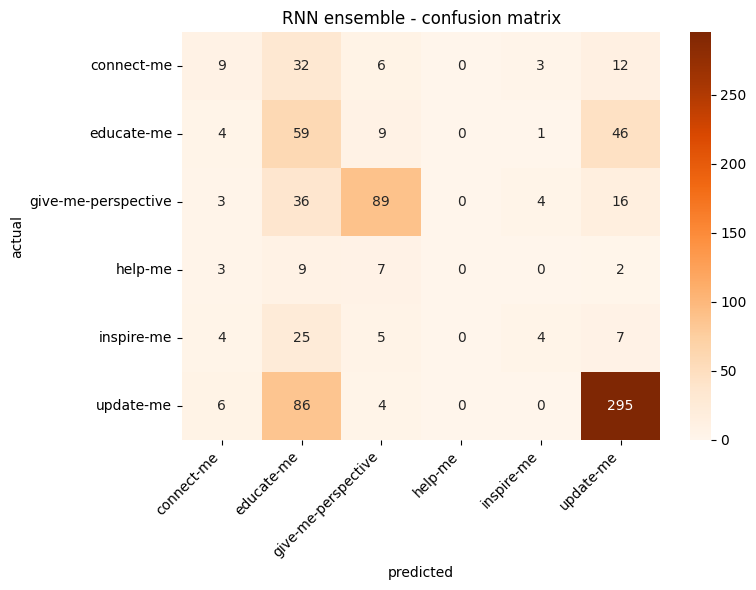

In [35]:
#ensemble confusion matrix
fig,ax= plt.subplots(figsize=(8,6))
cm_ens =confusion_matrix(y_test,ensemble_preds)
sns.heatmap(cm_ens,annot=True, fmt='d',cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,ax=ax)
ax.set_title('RNN ensemble - confusion matrix')
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Model Comparison


In [37]:
#compare all models
results= {
    'Naive Bayes': accuracy_score(y_test,nb_preds),
    'BERT Zero-Shot': accuracy_score(y_sample,zs_preds),
    'BERT Fine-tuned': bert_acc,
    'RNN Ensemble': accuracy_score(y_test,ensemble_preds),
    'LSTM only': accuracy_score(y_test,lstm_preds),
    'GRU only': accuracy_score(y_test,gru_preds),
    'BiLSTM only': accuracy_score(y_test, bilstm_preds)
}

#sort by accuracy
results_sorted= dict(sorted(results.items(),key=lambda x:x[1], reverse=True))

for name,acc in results_sorted.items():
    print(f'{name}: {acc:.4f}')

BERT Fine-tuned: 0.6705
Naive Bayes: 0.6145
RNN Ensemble: 0.5802
BiLSTM only: 0.5763
GRU only: 0.5636
LSTM only: 0.5611
BERT Zero-Shot: 0.2050


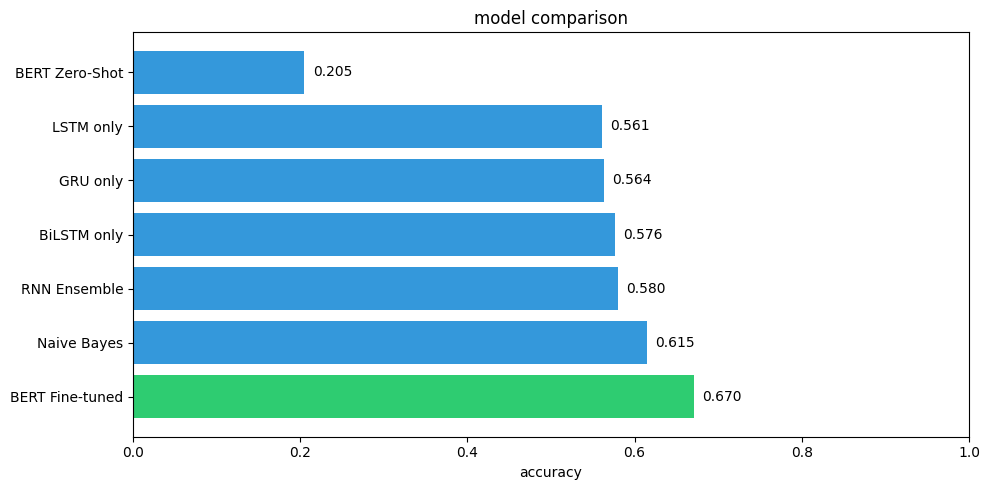


best model: BERT Fine-tuned


In [38]:
#bar chart comparison
fig,ax =plt.subplots(figsize=(10,5))
names= list(results_sorted.keys())
accs =list(results_sorted.values())
colors =['#2ecc71' if i==0 else '#3498db' for i in range(len(names))]
ax.barh(names,accs, color=colors)
ax.set_xlabel('accuracy')
ax.set_title('model comparison')
ax.set_xlim(0,1)
#add value labels
for i,v in enumerate(accs):
    ax.text(v+0.01,i, f'{v:.3f}',va='center')
plt.tight_layout()
plt.show()

best_name =names[0]
print(f'\nbest model: {best_name}')